Iniciando entrenamiento FAST en cpu...
--- Epoch 1 | Average Loss: 1.1010 ---
--- Epoch 2 | Average Loss: 1.0983 ---
--- Epoch 3 | Average Loss: 1.0979 ---
--- Epoch 4 | Average Loss: 1.0955 ---
--- Epoch 5 | Average Loss: 1.0986 ---
--- Epoch 6 | Average Loss: 1.0966 ---
--- Epoch 7 | Average Loss: 1.0938 ---
--- Epoch 8 | Average Loss: 1.0957 ---
--- Epoch 9 | Average Loss: 1.0949 ---
--- Epoch 10 | Average Loss: 1.0938 ---


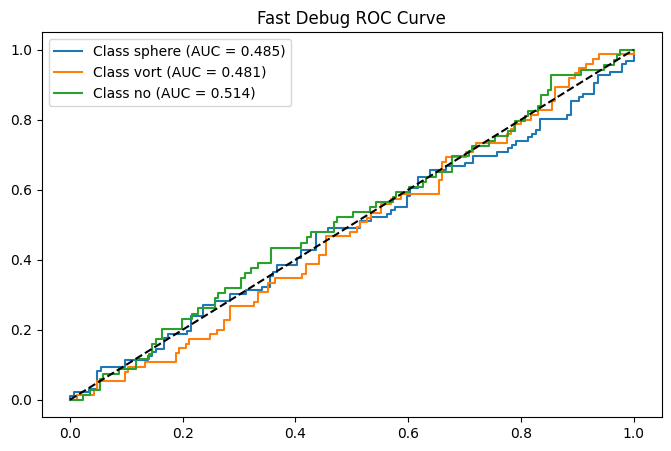

In [2]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

data_dir = "dataset_extraido/dataset/train" 
clases_encontradas = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')]
class_map = {nombre_clase: i for i, nombre_clase in enumerate(clases_encontradas)}

paths, labels = [], []
for class_name, label in class_map.items():

    files = glob.glob(os.path.join(data_dir, class_name, '*.npy'))[:800] 
    for f in files:
        paths.append(f)
        labels.append(label)

class LensingDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        img = np.load(self.file_paths[idx])
        if len(img.shape) == 2:
            img = np.expand_dims(img, axis=0)
        tensor_img = torch.tensor(img, dtype=torch.float32)
        
        # Min-Max
        t_min, t_max = tensor_img.min(), tensor_img.max()
        if t_max > t_min:
            tensor_img = (tensor_img - t_min) / (t_max - t_min)
        return tensor_img, torch.tensor(self.labels[idx], dtype=torch.long)

full_dataset = LensingDataset(paths, labels)
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_data, test_data = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

class FastLensingCNN(nn.Module):
    def __init__(self):
        super(FastLensingCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, len(class_map))
        )

    def forward(self, x):
        return self.classifier(self.features(x))

device = torch.device("cpu")
model = FastLensingCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

epochs = 10 
print(f"Iniciando entrenamiento FAST en {device}...")

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss/len(train_loader)
    print(f"--- Epoch {epoch} | Average Loss: {avg_loss:.4f} ---")

model.eval()
y_true, y_probs = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs)
        y_true.extend(targets.numpy())
        y_probs.extend(torch.softmax(outputs, dim=1).numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_bin = label_binarize(y_true, classes=list(class_map.values()))

plt.figure(figsize=(8, 5))
for i in range(len(class_map)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {list(class_map.keys())[i]} (AUC = {score:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Fast Debug ROC Curve')
plt.legend()
plt.show()

In [4]:
!pip install torch torchvision scikit-learn matplotlib numpy

  Using cached torch-2.11.0-cp314-cp314-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp314-cp314-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
Using cached torch-2.11.0-cp314-cp314-manylinux_2_28_x86_64.whl (530.7 MB)
Using cached torchvision-0.26.0-cp314-cp314-manylinux_2_28_x86_64.whl (7.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchvision] 1/2 [torchvision]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
